# Model Specification

**Purpose** : this notebook specifies 4 computational models (see `context/OSF_preregistration.md`) for the preregistered comparison. Code and implementation will be found in `notebooks/06_model_fitting.ipynb`. M1 is implemented with parameter recovery below, whilst M2 - M4 are specified in prose.

**Computational Models**
1. Null/flat — constant press probability, no learning
2. Task-specific Rescorla-Wagner RL — resets at task boundary
3. Property-indexed RL — SC belief transfers as prior to Task 2
4. Hierarchical Bayesian precision model — precision conditioned on property-indexed causal efficacy, distinguishes global/task/property priors      

**Goal** : the hypothesis motivating this experiment is that self-representation is formed on the basis of patterns of learnt contingency - the structure and properties denoting instances of agency are what is preserved in the self-model. This presents 2 falsifiable claims : 
- That the learning task involves extracting contingency, rather than causal structure, from the environment.      
- That self-representation stores the *properties* or affordances that reliably co-occur or signal this contingency.

To begin testing this hypothesis, I drew from the principles in *Falsification in Computational Cognitive Modeling* (Palminteri, Wyart, & Koechlin, 2017) - the models specified below challenge the claims at their computational level : does subjects' behaviour reflect task-outcome-driven RL, property-indexed RL, or Bayesian updating? 

## Shared Observation Model

> All four models share the same observation model: P(pressed = 1) = σ(β · V_t + b), where V_t is model-specific, β is inverse temperature, b is press bias.
- σ = logistic function
- β = inverse temperature
- V_t = model-specific model state
- b = press bias

The decision rule is logistic - equivalent to softmax over two actions, fitting a binary choice. It includes a press bias. 
This holds for all 4 models, enabling likelihood-based comparisons between them.

The trials entering the likelihood are Blocks 2 and 3, though Block 1 : Group A enters learning updates. Specifically:
- Block 1 is a training block with 'watch-only' constraints : there is no press data to inform the model. Group A, however, observes OC-trial outcomes (dot reversals reliably occurring when a certain property is present) and can therefore learn from this data. It will be included in learning updates for models with learning (M2 - M4).
- Block 2 affords both learning updates and likelihood, as it enables both groups to press, observe outcomes, and accumulate data on the different properties and related outcomes. It enters the likelihood and contributes to learning.
- Block 3 does not show outcomes, but affords a press for both groups - it contributes to the likelihood, but not to learning updates. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
min_trials = 5

# Same variables and objects set up in 02_EDA.ipynb - see that notebook for initial script. Nothing has been changed
df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_clean = df_clean.rename(columns={'prop_SC': 'sc_prop', 'prop_OC': 'oc_prop', 'prop_R': 'r_prop'})

trials = df_clean[df_clean['watch_only'] == 0].copy()
trials['pressed'] = trials['pressed'].astype(int)
trials['outcome'] = trials['outcome'].astype(int)

_t1   = df_clean[df_clean['task'] == 1].groupby('subject_id').first().reset_index()
_pall = trials.groupby('subject_id')['pressed'].mean().rename('overall_press_rate')
subject_meta = (
    _t1[['subject_id', 'group', 'sc_prop', 'oc_prop', 'r_prop', 'completion_min']]
    .merge(_pall, on='subject_id')
)

press_rates = (
    trials
    .groupby(['subject_id', 'group', 'sc_prop', 'task', 'block', 'trial_role'])
    .agg(
        n_trials   = ('pressed', 'count'),
        n_pressed  = ('pressed', 'sum'),
        press_rate = ('pressed', 'mean'),
        mean_rt    = ('rt',      'mean'),
    )
    .reset_index()
)
pr = press_rates[press_rates['n_trials'] >= min_trials].copy()

## Model 1 - null/flat

           N           k      p_hat      b_hat          LL
count   70.0   70.000000  70.000000  70.000000   70.000000
mean   160.0   77.442857   0.484018  -0.070086 -100.265153
std      0.0   28.445033   0.177781   0.806888   12.712839
min    160.0   19.000000   0.118750  -2.004321 -110.903549
25%    160.0   55.000000   0.343750  -0.646627 -109.888902
50%    160.0   75.500000   0.471875  -0.112623 -105.588024
75%    160.0   96.500000   0.603125   0.418555  -95.291523
max    160.0  137.000000   0.856250   1.784487  -58.308325


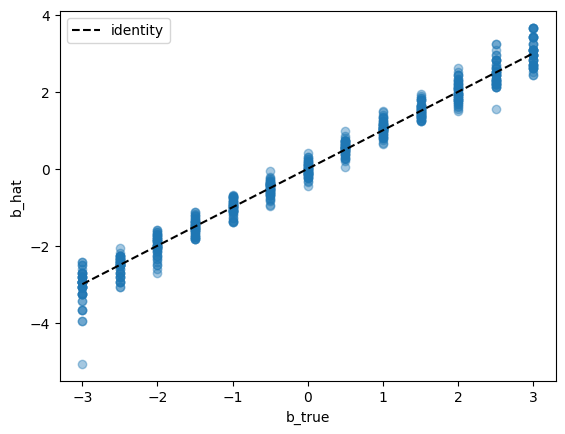

In [10]:
# Data simulation

n_trials = 160
inverse_temp = 1.0
b_true = 0.3
V_t = np.zeros(n_trials)

logits = inverse_temp * V_t + b_true
press_prob = 1 / (1 + np.exp(-logits))
presses = np.random.binomial(n=1, p=press_prob, size=n_trials)
press_rate = pd.Series(presses, name="press")


# b estimation

b_true_grid = np.linspace(-3, 3, 13)
n_reps = 50
results = []

for b_true in b_true_grid:
    for rep in range(n_reps):
        p = 1 / (1 + np.exp(-b_true))
        presses = np.random.binomial(1, p, size=n_trials)
        k = presses.sum()
        b_hat = np.log((k/n_trials) / (1 - k/n_trials + 1e-10))  # small epsilon avoids div by 0 at extremes
        results.append({'b_true': b_true, 'b_hat': b_hat})

df = pd.DataFrame(results)


# Fit M1 to real data, per subject

fit_results = []
for sub_id, sub_df in df_clean.groupby('subject_id'):
    press_trials = sub_df[sub_df.watch_only == 0]
    k = press_trials['pressed'].sum()
    N = len(press_trials)
    p_hat = k / N
    b_hat = np.log(p_hat / (1 - p_hat + 1e-10))
    LL = k * np.log(p_hat + 1e-10) + (N - k) * np.log(1 - p_hat + 1e-10)
    
    fit_results.append({
        'subject_id': sub_id, 'N': N, 'k': k, 'p_hat': p_hat, 
        'b_hat': b_hat, 'LL': LL
    })

m1_fits = pd.DataFrame(fit_results)
print(m1_fits.describe())

# Plot

plt.scatter(df['b_true'], df['b_hat'], alpha=0.4)
plt.plot([-3, 3], [-3, 3], 'k--', label='identity')
plt.xlabel('b_true')
plt.ylabel('b_hat')
plt.legend()
plt.show()

M1 fits a single press-bias parameter per subject with no learning. The recovery plot confirms that `b_hat` tracks `b_true` across the plausible range. This will set the baseline against which learning models will be compared via BIC.

## Model 2 - task-specific Rescorla-Wagner model

The Rescorla-Wagner model is the first of 2 RL models - it does not involve transfer of learning between tasks, but instead posits that property-based learning occurs within a task, and resets at the task boundary. Associative strength accumulates throughout.     

**Free parameters**
- α = value-level learning rate
- β = inverse temperature
- b = press bias
    
    
**Variables**
- ΔV = change in associative strength for a given property value (these are : `colour` ['red', 'blue], `size` ['large', 'small'], `velocity` ['fast', 'slow'] in T1, and `colour` ['green', 'purple'] in T2 - velocity and size remaining unchanged).
- V_total = total associative strength of all property values present
     
     
**Update rule** : allows for contingency learning, by separating active vs. passive learning
- Q(press | v) = Q(press | v) + α · (outcome − Q(press | v)) -> action-conditional        
- Q(no_press | v) = Q(no_press | v) + α · (outcome − Q(no_press | v)) -> symmetric to action-conditional Q-values.     
      
         
**Cumulative associative strength** : V_t = Σ over property values present on trial t of [Q(press | v) − Q(nopress | v)]
     
    
**Task transfer** : at the task boundary, all Q-values are reset to 0.5, regardless of whether the property values change. This forced reset is what makes M2 task-specific and distinguishes it from M3.

NOTE : during Block 3, as mentioned above, presses enter the likelihood but does not update Q-values 

---


## Model 3 - property-indexed RL

This is the second of the two RL models, and distinguishes itself by its inclusion of *property-indexed learning* : specifically, learning that transfers across tasks, rather than maintains a property-value specificity. It abstracts up by one level.

**Free parameters** : four parameters - one incremental from the Rescorla-Wagner model (λ).
- α = value-level learning rate
- λ = property-level learning rate
- β = inverse temperature
- b = press bias

**Variables**
- ΔV_v = change in associative strength for a given property value (these are : `colour` ['red', 'blue], `size` ['large', 'small'], `velocity` ['fast', 'slow'] in T1, and `colour` ['green', 'purple'] in T2 - velocity and size remaining unchanged).
- ΔV_p = change in associative strength for a given property
- V_total = total associative strength of all properties present

**Update rules** : same action-conditional Q-values as M2 at the value level. The additions are property-level scalars tracking how informative each property-type is, updated as a leaky average of the value-level contingency magnitude.
- Q_prop(colour)
- Q_prop(size)
- Q_prop(velocity)

**Cumulative associative strength** : V_t = Σ over property values present on trial t of [Q(press | v) − Q(nopress | v)].  
*V_t is computed identically to M2 : the property-level Q_prop enters only as the initialisation value for new property values at the task boundary, not in the per-trial decision*

**Task transfer** : value-level Qs for unchanged properties (size, velocity if not colour-SC) carry over directly. The value-level Qs for changed properties (new colour values in task 2) initialise at Q_prop(colour), not at zero. Q_prop itself transfers fully.
This encodes the commitment to property-indexed learning. As a simpler way to put it, subjects expect that "having learnt colour matters; I don't yet know which new colour value matters, but I expect one of them to."


NOTE : the prediction that distinguishes M3 from M2 is that the former OC property enters task 2 carrying the contingency-belief it accumulated in task 1 (now assigned to the R role). The former R property does the same, despite the change in assignment, as does SC.      
Overall, M3 predicts elevated initial press rates on former-OC trials in early task 2. M2 does not.

## Model 4 - hierarchical Bayesian precision model

M4 moves away from an RL regime, and follows a Bayesian one instead. It maintains posterior distributions over property-level contingency, rather than Q-values, with updates being precision-weighted instead. High-precision beliefs resist revision, while low-precision beliefs update readily.

**Hierarchical structure** : subject-level parameters will be drawn from group-level distributions, as defined below. This will enable the model to learn individual-level precision, and population-level regularities.
1. Global : overall tendency to press - press-bias
2. Task : task specific press base rates
3. Property-level : per-property contingency distributions

**Free parameters**
- η = update step size
- β = inverse temperature
- b = press bias
- wi = prior precision, property-specific   



M4 claims that what transfers is not a point estimate but a precision-weighted distribution. AKA, a property with high precision (OC, for example) should transfer more rigidly than one with low precision.

> Full specification is deferred to implementation for now, as exact parameterisation will depend on the posterior update implementation choice (Kalman filter vs. particle filter vs. variational).

# Planned Model Comparison

This follows the pre-registered analysis plan, which is to compare using the following measures:

1. Per-subject MLE fitting for M1–M4
2. Model comparison via BIC and AIC (also subject level)
3. Group-level inference via protected exceedance probability
4. Posterior predictive check: the winning model must reproduce the qualitative patterns from H1–H4 (SC-R gap, transfer index, block 3 persistence).

*Falsification in Computational Cognitive Modeling* (Palminteri, Wyart, & Koechlin, 2017)      
*Decision Making, Affect, and Learning: Attention and Performance XXIII* (Delgado, Phelps, & Robbins, 2011)        
*Ten simple rules for the computational modeling of behavioral data* (Wilson & Collins, 2019)